In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

df = pd.read_sql("SELECT * FROM ohlcv ORDER BY ticker, time", engine)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["ticker", "time"]).reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Tickers: {df['ticker'].unique()}")
print(f"Date range: {df['time'].min()} → {df['time'].max()}")
df.head()

Total rows: 11822
Tickers: ['ASII.JK' 'BBCA.JK' 'BBRI.JK' 'BMRI.JK' 'BYAN.JK' 'EMTK.JK' 'GOTO.JK'
 'ICBP.JK' 'TLKM.JK' 'UNVR.JK']
Date range: 2021-06-25 00:00:00+00:00 → 2026-06-25 00:00:00+00:00


,time,ticker,open,high,low,close,volume
0,2021-06-25 00:00:00+00:00,ASII.JK,3348.032816,3375.142394,3327.700633,3334.478027,33125300
1,2021-06-28 00:00:00+00:00,ASII.JK,3334.477863,3341.255257,3192.152588,3192.152588,53083400
2,2021-06-29 00:00:00+00:00,ASII.JK,3205.707453,3334.477943,3192.152665,3280.258789,70425700
3,2021-06-30 00:00:00+00:00,ASII.JK,3273.481618,3388.697327,3266.704223,3348.032959,34641700
4,2021-07-01 00:00:00+00:00,ASII.JK,3381.919745,3456.471082,3354.810168,3405.640625,42856900


In [2]:
# Cek missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Basic statistics per ticker
print("\n=== Basic Stats (Close Price) ===")
df.groupby("ticker")["close"].describe().round(2)

=== Missing Values ===
time      0
ticker    0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

=== Basic Stats (Close Price) ===


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
ASII.JK,1202.0,4578.85,730.27,3151.49,4091.76,4398.49,4903.95,7044.31
BBCA.JK,1202.0,7652.28,1116.84,4850.00,6764.91,7799.06,8378.25,10060.58
BBRI.JK,1202.0,3585.33,548.10,2399.20,3231.22,3512.19,3957.53,5216.77
BMRI.JK,1202.0,4042.12,999.12,2005.53,3399.32,4166.33,4661.81,6094.77
BYAN.JK,1202.0,13303.16,6598.44,1109.77,6077.38,16979.26,18300.00,21629.09
EMTK.JK,1202.0,1012.44,607.97,322.91,509.05,753.27,1519.09,2740.91
GOTO.JK,1004.0,108.23,81.98,50.00,60.75,79.00,110.00,404.00
ICBP.JK,1202.0,9330.28,1444.79,6000.00,8088.48,9550.00,10545.88,12498.82
TLKM.JK,1202.0,2894.94,379.20,1962.76,2572.34,2977.23,3198.67,3681.84


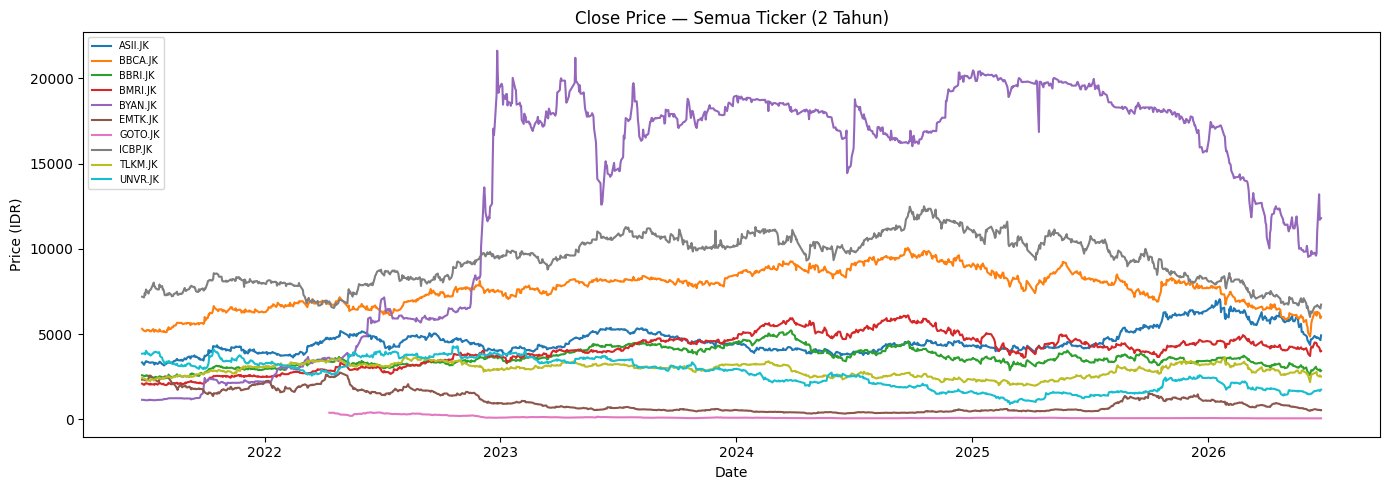

In [3]:
# Cek distribusi volume
plt.figure(figsize=(14, 5))
for i, ticker in enumerate(df["ticker"].unique()):
    subset = df[df["ticker"] == ticker]
    plt.plot(subset["time"], subset["close"], label=ticker)

plt.title("Close Price — Semua Ticker (2 Tahun)")
plt.xlabel("Date")
plt.ylabel("Price (IDR)")
plt.legend(loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

In [4]:
import ta

def add_technical_indicators(df_ticker):
    df_t = df_ticker.copy().sort_values("time")
    
    # Trend Indicators
    df_t["ema_20"]        = ta.trend.ema_indicator(df_t["close"], window=20)
    df_t["ema_50"]        = ta.trend.ema_indicator(df_t["close"], window=50)
    df_t["macd"]          = ta.trend.macd(df_t["close"])
    df_t["macd_signal"]   = ta.trend.macd_signal(df_t["close"])
    df_t["macd_diff"]     = ta.trend.macd_diff(df_t["close"])

    # Momentum Indicators
    df_t["rsi"]           = ta.momentum.rsi(df_t["close"], window=14)
    df_t["stoch"]         = ta.momentum.stoch(df_t["high"], df_t["low"], df_t["close"])

    # Volatility Indicators
    df_t["bb_high"]       = ta.volatility.bollinger_hband(df_t["close"])
    df_t["bb_low"]        = ta.volatility.bollinger_lband(df_t["close"])
    df_t["bb_mid"]        = ta.volatility.bollinger_mavg(df_t["close"])
    df_t["bb_width"]      = ta.volatility.bollinger_wband(df_t["close"])
    df_t["atr"]           = ta.volatility.average_true_range(df_t["high"], df_t["low"], df_t["close"])

    # Volume Indicators
    df_t["obv"]           = ta.volume.on_balance_volume(df_t["close"], df_t["volume"])
    df_t["vwap"]          = ta.volume.volume_weighted_average_price(
                                df_t["high"], df_t["low"], df_t["close"], df_t["volume"])

    # Price-derived features
    df_t["returns"]       = df_t["close"].pct_change()
    df_t["log_returns"]   = np.log(df_t["close"] / df_t["close"].shift(1))
    df_t["hl_spread"]     = (df_t["high"] - df_t["low"]) / df_t["close"]
    df_t["price_range"]   = df_t["high"] - df_t["low"]

    # Target variable — prediksi arah besok (1=naik, 0=turun)
    df_t["target"]        = (df_t["close"].shift(-1) > df_t["close"]).astype(int)

    return df_t

# Apply ke semua ticker
df_featured = df.groupby("ticker", group_keys=False).apply(add_technical_indicators)
df_featured = df_featured.dropna().reset_index(drop=True)

print(f"Rows setelah feature engineering: {len(df_featured)}")
print(f"Features: {df_featured.columns.tolist()}")

Rows setelah feature engineering: 11316
Features: ['time', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'ema_20', 'ema_50', 'macd', 'macd_signal', 'macd_diff', 'rsi', 'stoch', 'bb_high', 'bb_low', 'bb_mid', 'bb_width', 'atr', 'obv', 'vwap', 'returns', 'log_returns', 'hl_spread', 'price_range', 'target']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17552\450017901.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_featured = df.groupby("ticker", group_keys=False).apply(add_technical_indicators)


In [5]:
# Plot candlestick + Bollinger Bands untuk 1 ticker
ticker = "BBCA.JK"
sample = df_featured[df_featured["ticker"] == ticker].tail(60)

fig = go.Figure()

fig.add_trace(go.Candlestick(
    x=sample["time"],
    open=sample["open"], high=sample["high"],
    low=sample["low"], close=sample["close"],
    name="OHLCV"
))

fig.add_trace(go.Scatter(x=sample["time"], y=sample["bb_high"], 
    line=dict(color="red", width=1), name="BB High"))
fig.add_trace(go.Scatter(x=sample["time"], y=sample["bb_low"],
    line=dict(color="green", width=1), name="BB Low"))
fig.add_trace(go.Scatter(x=sample["time"], y=sample["bb_mid"],
    line=dict(color="blue", width=1, dash="dash"), name="BB Mid"))

fig.update_layout(title=f"{ticker} — Candlestick + Bollinger Bands (60 hari terakhir)",
                  xaxis_rangeslider_visible=False, height=500)
fig.show()

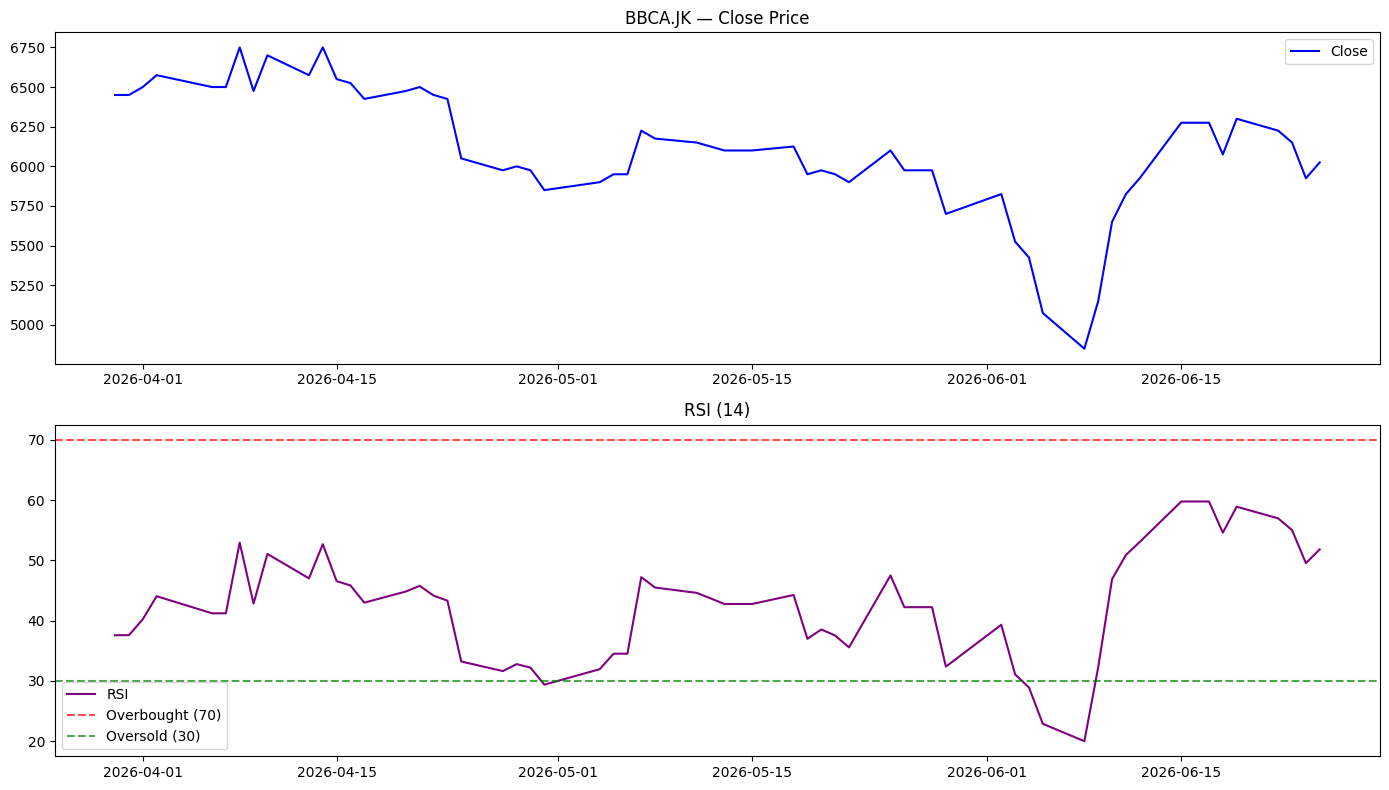

In [6]:
# Plot RSI
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(sample["time"], sample["close"], label="Close", color="blue")
axes[0].set_title(f"{ticker} — Close Price")
axes[0].legend()

axes[1].plot(sample["time"], sample["rsi"], label="RSI", color="purple")
axes[1].axhline(70, color="red", linestyle="--", alpha=0.7, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[1].set_title("RSI (14)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Load news data
df_news = pd.read_sql("SELECT * FROM news_raw ORDER BY published_at", engine)
df_news["published_at"] = pd.to_datetime(df_news["published_at"])

# Normalize ticker format
df_news["ticker"] = df_news["ticker"].str.replace(".JK", "", regex=False)

print(f"Total news: {len(df_news)}")
df_news.head()

Total news: 1023


,id,source,ticker,title,content,url,published_at,created_at
0,30,Yahoo Finance,BBRI,,,,1970-01-01 00:00:00+00:00,2026-06-23 07:56:14.208053+00:00
1,310,Google News,BMRI,Chart dan Harga Saham BMRI — IDX:BMRI - Tradin...,"<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiV0FVX...,2018-02-27 17:57:11+00:00,2026-06-25 09:20:42.951678+00:00
2,345,Google News,BMRI,"Harga Saham Mandiri Belum Stabil, Cocok Untuk ...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMikgFBV...,2019-10-02 07:00:00+00:00,2026-06-25 09:20:42.951678+00:00
3,1045,Google News,EMTK,"Saham Emtek (EMTK) Kena ARB Berhari-Hari, Ada ...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMirwFBV...,2022-05-17 07:00:00+00:00,2026-06-25 09:20:55.806116+00:00
4,340,Google News,BMRI,"🪙 Analisis Sektor Perbankan: Saham BBCA, BMRI,...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMia0FVX...,2022-06-06 07:00:00+00:00,2026-06-25 09:20:42.951678+00:00


In [ ]:
from transformers import pipeline


sentiment_pipeline = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=-1  
)

def get_sentiment(text):
    if not text or pd.isna(text):
        return "neutral", 0.0
    try:
        text = str(text)[:512]  
        result = sentiment_pipeline(text)[0]
        label = result["label"].lower()
        score = result["score"]
        numeric = {"positive": 1, "neutral": 0, "negative": -1}.get(label, 0)
        return label, round(numeric * score, 4)
    except:
        return "neutral", 0.0

print("Running sentiment analysis...")
df_news["text"] = df_news["title"] + ". " + df_news["content"].fillna("")
df_news[["sentiment_label", "sentiment_score"]] = df_news["text"].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(df_news[["ticker", "title", "sentiment_label", "sentiment_score"]].head(10))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running sentiment analysis...
  ticker                                              title sentiment_label  \
0   BBRI                                                            neutral   
1   BMRI  Chart dan Harga Saham BMRI — IDX:BMRI - Tradin...         neutral   
2   BMRI  Harga Saham Mandiri Belum Stabil, Cocok Untuk ...         neutral   
3   EMTK  Saham Emtek (EMTK) Kena ARB Berhari-Hari, Ada ...         neutral   
4   BMRI  🪙 Analisis Sektor Perbankan: Saham BBCA, BMRI,...         neutral   
5   EMTK  7 Perusahaan Emtek Group yang Ada Di BEI - Sto...         neutral   
6   BMRI  Proyeksi BMRI — Target Harga untuk 2027 - Trad...         neutral   
7   BMRI  Dividen PT Bank Mandiri (Persero) Tbk – IDX:BM...         neutral   
8   BMRI  Segini Harga 1 Lot Saham Bank Mandiri, Apakah ...         neutral   
9   BMRI  Ini Dia Rentetan Jadwal Stock Split Bank Mandi...         neutral   

   sentiment_score  
0              0.0  
1              0.0  
2              0.0  
3              0

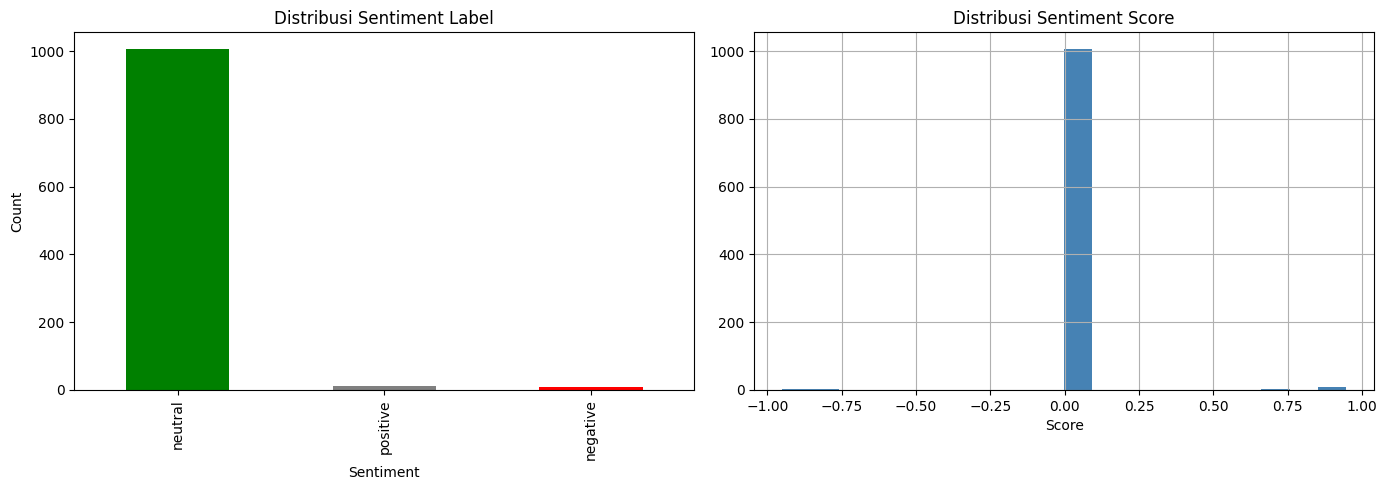

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_news["sentiment_label"].value_counts().plot(
    kind="bar", ax=axes[0], color=["green","gray","red"]
)
axes[0].set_title("Distribusi Sentiment Label")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

df_news["sentiment_score"].hist(bins=20, ax=axes[1], color="steelblue")
axes[1].set_title("Distribusi Sentiment Score")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

In [ ]:
df_featured.to_sql("ohlcv_featured", engine, if_exists="replace", index=False)
print(f"ohlcv_featured saved: {len(df_featured)} rows")

df_news.to_sql("news_sentiment", engine, if_exists="replace", index=False)
print(f"news_sentiment saved: {len(df_news)} rows")

ohlcv_featured saved: 11316 rows
news_sentiment saved: 1023 rows


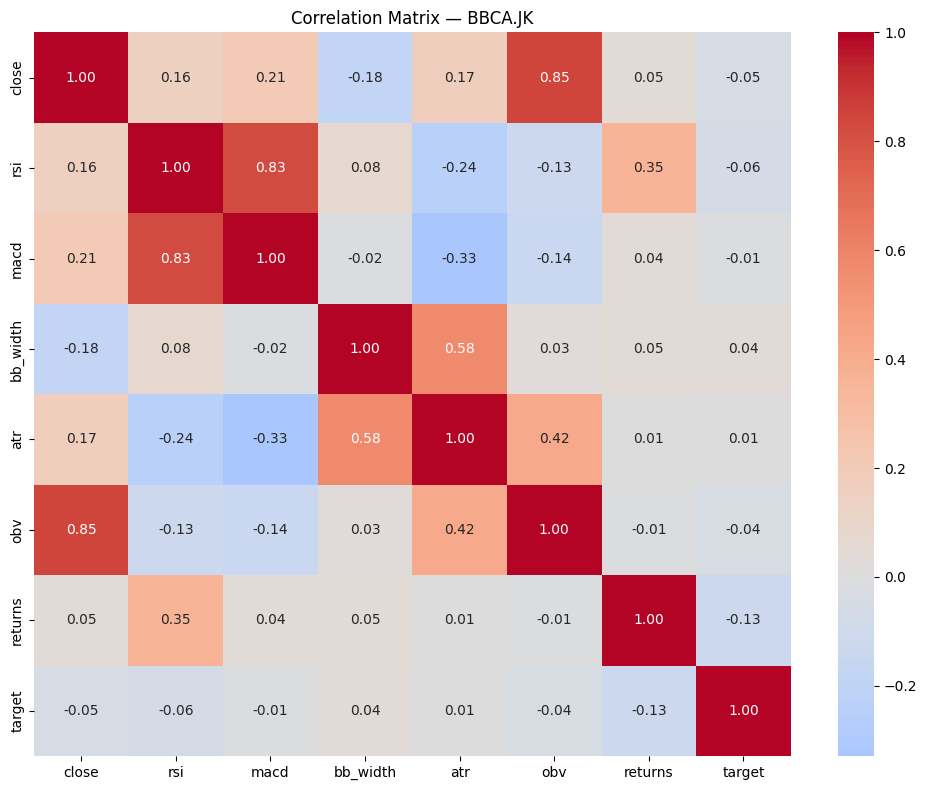

In [ ]:
ticker = "BBCA.JK"
sample_corr = df_featured[df_featured["ticker"] == ticker]

feature_cols = ["close","rsi","macd","bb_width","atr","obv","returns","target"]
corr_matrix = sample_corr[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title(f"Correlation Matrix — {ticker}")
plt.tight_layout()
plt.show()